# Implicit Reparameterization Trick: Computation Graphs

Демонстрация метода `rsample()` для всех распределений из библиотеки `irt.distributions`.  
Для каждого распределения показываем:
- семплирование с помощью `rsample()`
- вычисление градиентов по параметрам
- визуализацию вычислительного графа через `torchviz`

In [1]:
%load_ext autoreload
%autoreload 2

import torch
import torchviz
import sys
sys.path.append('../src')

import irt
import irt.distributions

---
## `sample()` vs `rsample()`

Метод `sample()` не сохраняет вычислительный граф — `backward()` вызовет ошибку.  
Метод `rsample()` (reparameterized sample) позволяет протянуть градиенты через семплирование.

In [2]:
mu = torch.tensor([0.0], requires_grad=True)
sigma = torch.tensor([1.0], requires_grad=True)

# sample() — нет вычислительного графа
m = irt.distributions.Normal(mu, sigma)
try:
    z = m.sample()
    loss = (z ** 2).sum()
    loss.backward()
    print('sample()  — backward succeeded')
except RuntimeError:
    print('sample()  — backward failed (no computation graph)')

# rsample() — градиенты протекают
mu = torch.tensor([0.0], requires_grad=True)
sigma = torch.tensor([1.0], requires_grad=True)
m = irt.distributions.Normal(mu, sigma)

z = m.rsample()
loss = (z ** 2).sum()
loss.backward()

print(f'rsample() — z = {z.item():.4f}')
print(f'  mu.grad    = {mu.grad}')
print(f'  sigma.grad = {sigma.grad}')

sample()  — backward failed (no computation graph)
rsample() — z = 0.0995
  mu.grad    = tensor([0.1989])
  sigma.grad = tensor([0.0198])


---
## 1. Normal

Нормальное распределение $\mathcal{N}(\mu, \sigma^2)$.

mu.grad    = tensor([-2.1482, -1.1850])
sigma.grad = tensor([3.3815, 1.2580])


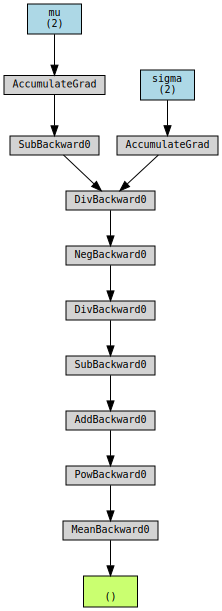

In [3]:
mu = torch.tensor([1.0, 2.0], requires_grad=True)
sigma = torch.tensor([2.0, 3.0], requires_grad=True)

z = irt.distributions.Normal(mu, sigma).rsample()
loss = torch.mean(z ** 2)
loss.backward(retain_graph=True)

print(f'mu.grad    = {mu.grad}')
print(f'sigma.grad = {sigma.grad}')
torchviz.make_dot(loss, params={'mu': mu, 'sigma': sigma})

---
## 2. Gamma

Гамма-распределение $\text{Gamma}(\alpha, \beta)$.

alpha.grad = tensor([1.1350, 0.1720])
beta.grad  = tensor([-0.7929, -0.0946])


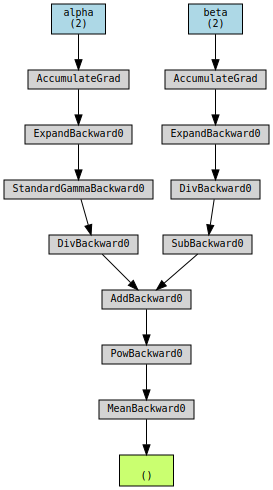

In [4]:
alpha = torch.tensor([1.0, 2.0], requires_grad=True)
beta = torch.tensor([2.0, 3.0], requires_grad=True)

z = irt.distributions.Gamma(alpha, beta).rsample()
loss = torch.mean(z ** 2)
loss.backward(retain_graph=True)

print(f'alpha.grad = {alpha.grad}')
print(f'beta.grad  = {beta.grad}')
torchviz.make_dot(loss, params={'alpha': alpha, 'beta': beta})

---
## 3. Beta

Бета-распределение $\text{Beta}(\alpha, \beta)$.

alpha.grad = tensor([0.0322])
beta.grad  = tensor([-0.0074])


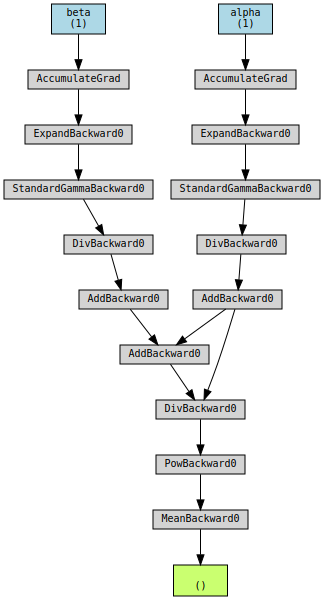

In [5]:
alpha = torch.tensor([1.0], requires_grad=True)
beta = torch.tensor([2.0], requires_grad=True)

z = irt.distributions.Beta(alpha, beta).rsample()
loss = torch.mean(z ** 2)
loss.backward(retain_graph=True)

print(f'alpha.grad = {alpha.grad}')
print(f'beta.grad  = {beta.grad}')
torchviz.make_dot(loss, params={'alpha': alpha, 'beta': beta})

---
## 4. Dirichlet

Распределение Дирихле $\text{Dir}(\alpha_1, \ldots, \alpha_K)$.

alpha.grad = tensor([-0.0040, -0.0005, -0.0033,  0.0004,  0.0009])


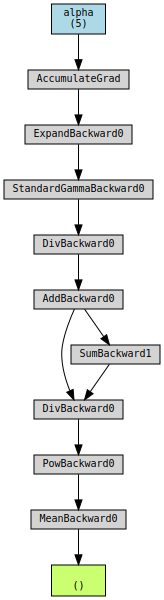

In [6]:
alpha = torch.tensor([1.0, 2.0, 3.0, 4.0, 5.0], requires_grad=True)

z = irt.distributions.Dirichlet(alpha).rsample((2,))
loss = torch.mean(z ** 2)
loss.backward(retain_graph=True)

print(f'alpha.grad = {alpha.grad}')
torchviz.make_dot(loss, params={'alpha': alpha})

---
## 5. Student-t

Распределение Стьюдента $t(\nu, \mu, \sigma)$.

df.grad    = tensor([ 0.2306, -0.2346])
loc.grad   = tensor([ 1.3397, -0.8081])
scale.grad = tensor([-0.8846,  1.5386])


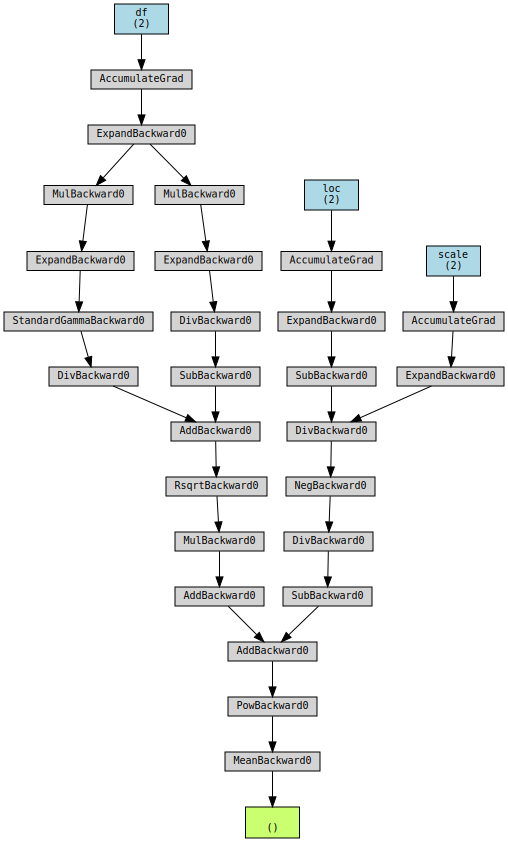

In [7]:
df = torch.tensor([1.0, 2.0], requires_grad=True)
loc = torch.tensor([2.0, 3.0], requires_grad=True)
scale = torch.tensor([1.0, 2.0], requires_grad=True)

z = irt.distributions.StudentT(df, loc, scale).rsample()
loss = torch.mean(z ** 2)
loss.backward(retain_graph=True)

print(f'df.grad    = {df.grad}')
print(f'loc.grad   = {loc.grad}')
print(f'scale.grad = {scale.grad}')
torchviz.make_dot(loss, params={'df': df, 'loc': loc, 'scale': scale})

---
## 6. Von Mises

Распределение фон Мизеса для циклических данных с параметрами $\text{loc}$ и $\text{concentration}$ ($\kappa$).

loc.grad           = tensor([1.1701, 0.3584])
concentration.grad = tensor([-0.4819,  0.0256])


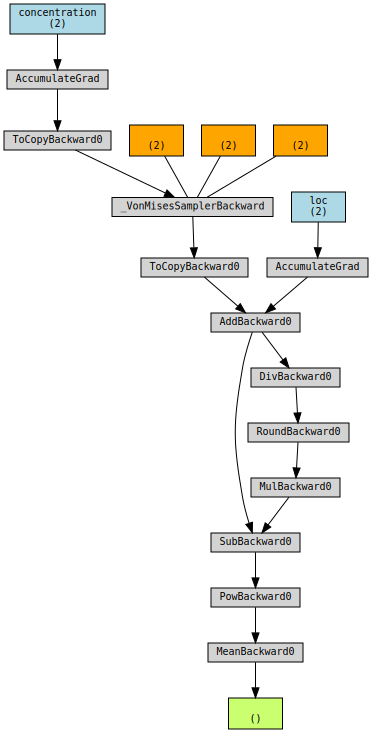

In [8]:
loc = torch.tensor([0.0, 1.0], requires_grad=True)
concentration = torch.tensor([2.0, 5.0], requires_grad=True)

z = irt.distributions.VonMises(loc, concentration).rsample()
loss = torch.mean(z ** 2)
loss.backward(retain_graph=True)

print(f'loc.grad           = {loc.grad}')
print(f'concentration.grad = {concentration.grad}')
torchviz.make_dot(loss, params={'loc': loc, 'concentration': concentration})

---
## 7. MixtureSameFamily

Смесь распределений одного семейства. Пример: смесь двух нормальных распределений с репараметризованным семплированием.

mix_logits.grad = tensor([-1.2374,  1.2374])
comp_loc.grad   = tensor([4.8375e-13, 3.6567e+00])
comp_scale.grad = tensor([ 3.7039e-12, -1.2553e+00])


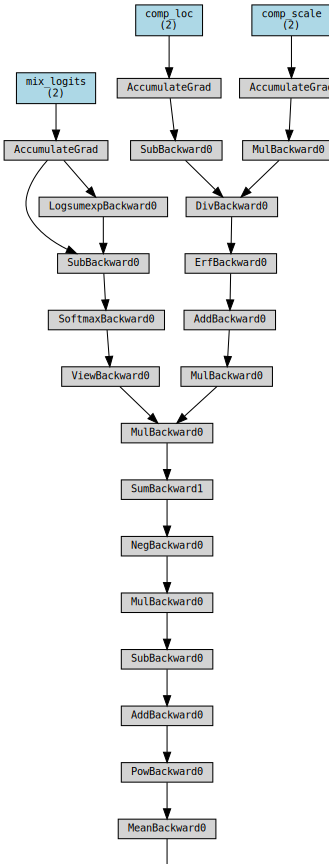

In [9]:
mix_logits = torch.tensor([0.3, 0.7], requires_grad=True)
comp_loc = torch.tensor([-2.0, 2.0], requires_grad=True)
comp_scale = torch.tensor([0.5, 0.5], requires_grad=True)

mixture = irt.distributions.MixtureSameFamily(
    mixture_distribution=torch.distributions.Categorical(logits=mix_logits),
    component_distribution=irt.distributions.Normal(comp_loc, comp_scale),
)
z = mixture.rsample()
loss = torch.mean(z ** 2)
loss.backward(retain_graph=True)

print(f'mix_logits.grad = {mix_logits.grad}')
print(f'comp_loc.grad   = {comp_loc.grad}')
print(f'comp_scale.grad = {comp_scale.grad}')
torchviz.make_dot(loss, params={'mix_logits': mix_logits, 'comp_loc': comp_loc, 'comp_scale': comp_scale})

---
## 8. ImplicitReparam (universal wrapper)

Обёртка `ImplicitReparam` позволяет добавить `rsample()` к произвольному распределению, у которого есть `cdf()` и `log_prob()`.  
Пример: оборачиваем `torch.distributions.Laplace`.

loc.grad   = tensor([1.3057, 2.9414])
scale.grad = tensor([1.7048, 2.8553])


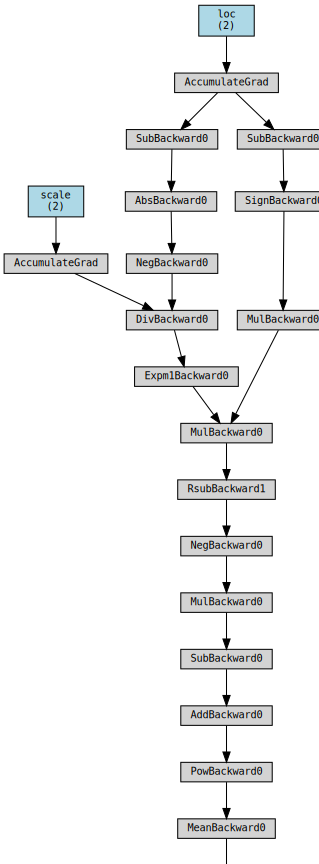

In [10]:
loc = torch.tensor([0.0, 1.0], requires_grad=True)
scale = torch.tensor([1.0, 2.0], requires_grad=True)

base = torch.distributions.Laplace(loc, scale)
dist = irt.distributions.ImplicitReparam(base)
z = dist.rsample()
loss = torch.mean(z ** 2)
loss.backward(retain_graph=True)

print(f'loc.grad   = {loc.grad}')
print(f'scale.grad = {scale.grad}')
torchviz.make_dot(loss, params={'loc': loc, 'scale': scale})

---
## Валидация: сравнение с численным градиентом

Для каждого распределения оцениваем $\frac{\partial}{\partial \theta} \mathbb{E}_{z \sim q_\theta}[f(z)]$ двумя способами:

1. **Implicit reparam** — через `rsample()` + `backward()`
2. **Finite differences** — через $\frac{\mathbb{E}[f(z)]|_{\theta+\varepsilon} - \mathbb{E}[f(z)]|_{\theta-\varepsilon}}{2\varepsilon}$

Если реализация корректна, оба значения должны быть близки.

In [11]:
import pandas as pd

NUM_SAMPLES = 100000
EPS = 1e-3


def finite_difference_gradient(make_dist_fn, param_val, f_fn, eps=EPS, num_samples=NUM_SAMPLES):
    """Оценка градиента конечными разностями."""
    dist_plus = make_dist_fn(param_val + eps)
    dist_minus = make_dist_fn(param_val - eps)

    torch.manual_seed(0)
    e_plus = f_fn(dist_plus.rsample(torch.Size([num_samples]))).mean()
    torch.manual_seed(0)
    e_minus = f_fn(dist_minus.rsample(torch.Size([num_samples]))).mean()

    return ((e_plus - e_minus) / (2 * eps)).item()


def implicit_reparam_gradient(make_dist_fn, param_val, f_fn, num_samples=NUM_SAMPLES):
    """Оценка градиента через implicit reparameterization."""
    param = torch.tensor(param_val, requires_grad=True)
    dist = make_dist_fn(param)
    torch.manual_seed(42)
    samples = dist.rsample(torch.Size([num_samples]))
    loss = f_fn(samples).mean()
    loss.backward()
    return param.grad.item()


# Набор тестов: (название, параметр, make_dist, param_val, f, описание)
tests = [
    ("Normal",
     "loc",
     lambda p: irt.distributions.Normal(p, 1.5),
     2.0, lambda x: x,
     "d/d(loc) E[x]"),

    ("Normal",
     "scale",
     lambda p: irt.distributions.Normal(0.0, p),
     2.0, lambda x: x ** 2,
     "d/d(scale) E[x²]"),

    ("Gamma",
     "concentration",
     lambda p: irt.distributions.Gamma(p, 1.0),
     3.0, lambda x: x,
     "d/d(α) E[x]"),

    ("Gamma",
     "rate",
     lambda p: irt.distributions.Gamma(3.0, p),
     2.0, lambda x: x,
     "d/d(β) E[x]"),

    ("Beta",
     "concentration1",
     lambda p: irt.distributions.Beta(p, 2.0),
     3.0, lambda x: x,
     "d/d(α) E[x]"),

    ("Student-t",
     "loc",
     lambda p: irt.distributions.StudentT(5.0, p, 1.0),
     1.0, lambda x: x,
     "d/d(loc) E[x]"),

    ("Student-t",
     "scale",
     lambda p: irt.distributions.StudentT(10.0, 0.0, p),
     2.0, lambda x: x ** 2,
     "d/d(scale) E[x²]"),

    ("VonMises",
     "loc",
     lambda p: irt.distributions.VonMises(p, 5.0),
     0.5, lambda x: torch.cos(x),
     "d/d(loc) E[cos(x)]"),

    ("VonMises",
     "concentration",
     lambda p: irt.distributions.VonMises(0.0, p),
     5.0, lambda x: torch.cos(x),
     "d/d(κ) E[cos(x)]"),

    ("ImplicitReparam (Laplace)",
     "loc",
     lambda p: irt.distributions.ImplicitReparam(torch.distributions.Laplace(p, 1.0)),
     1.0, lambda x: x,
     "d/d(loc) E[x]"),
]

rows = []
for name, param_name, make_dist, param_val, f_fn, description in tests:
    grad_irt = implicit_reparam_gradient(make_dist, param_val, f_fn)
    grad_fd = finite_difference_gradient(make_dist, param_val, f_fn)
    rows.append({
        "Distribution": name,
        "Parameter": param_name,
        "Test": description,
        "Implicit Reparam": f"{grad_irt:.4f}",
        "Finite Diff": f"{grad_fd:.4f}",
        "Δ (abs)": f"{abs(grad_irt - grad_fd):.4f}",
        "✓": "✅" if abs(grad_irt - grad_fd) < 0.15 else "❌",
    })

df = pd.DataFrame(rows)
df.style.hide(axis="index")

Distribution,Parameter,Test,Implicit Reparam,Finite Diff,Δ (abs),✓
Normal,loc,d/d(loc) E[x],1.0000,1.0000,0.0000,✅
Normal,scale,d/d(scale) E[x²],4.0475,4.0102,0.0373,✅
Gamma,concentration,d/d(α) E[x],1.0001,1.0029,0.0028,✅
Gamma,rate,d/d(β) E[x],-0.7503,-0.7513,0.0010,✅
Beta,concentration1,d/d(α) E[x],0.0800,0.0808,0.0008,✅
Student-t,loc,d/d(loc) E[x],1.0000,1.0000,0.0000,✅
Student-t,scale,d/d(scale) E[x²],4.9957,5.0187,0.0230,✅
VonMises,loc,d/d(loc) E[cos(x)],-0.4291,-0.4294,0.0004,✅
VonMises,concentration,d/d(κ) E[cos(x)],0.0232,0.0342,0.0110,✅
ImplicitReparam (Laplace),loc,d/d(loc) E[x],1.0000,1.0000,0.0000,✅
